# Core Paper Analysis: Open-Source LLMs vs Humans

Main analysis notebook for all open-source models and human benchmarks.

## Setup

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.proportion import proportion_confint, proportions_ztest
from sklearn.linear_model import LogisticRegression

from adjustText import adjust_text

import warnings
warnings.filterwarnings('ignore')


# Plot style settings
plt.rcParams['font.size'] = 9
plt.rcParams['font.family'] = 'sans-serif'

## 1. Load Data

In [23]:
# Load preprocessed data
ai_df = pd.read_csv('data/aidata.csv')
human_df = pd.read_csv('data/hudata.csv')

print("=== DATA LOADED ===")
print(f"AI (open-source): {len(ai_df):,} decisions")
print(f"  Models: {ai_df['model'].nunique()}")
print(f"  Roles: {', '.join(ai_df['role'].unique())}")
print(f"\nHuman: {len(human_df):,} decisions")
print(f"  Roles: {', '.join(human_df['role'].unique())}")

=== DATA LOADED ===
AI (open-source): 339,956 decisions
  Models: 17
  Roles: proposer, responder

Human: 4,166 decisions
  Roles: responder, proposer


## 2. Data Preparation


In [24]:
def summarize_group(df, role, label):
    sub = df[df["role"]==role]
    n = sub["prosocial"].notna().sum()
    s = sub["prosocial"].sum()
    rate = s / n if n else np.nan
    ci_low, ci_high = proportion_confint(s, n, alpha=0.05, method="wilson") if n else (np.nan, np.nan)
    return {"role": role, "group": label, "n": n, "prosocial_n": int(s), "rate": rate, "ci_low": ci_low, "ci_high": ci_high}

rows = []
for r in ["proposer", "responder"]:
    rows.append(summarize_group(human_df, r, "Humans"))
    rows.append(summarize_group(ai_df,   r, "AI"))
summary_df = pd.DataFrame(rows)

print("=== Baseline prosociality: Humans vs AI by role ===")
display(summary_df.assign(rate=lambda d: d["rate"].round(3),
                          ci_low=lambda d: d["ci_low"].round(3),
                          ci_high=lambda d: d["ci_high"].round(3)))

# Two-proportion z-tests (Humans vs AI) per role
print("\n=== Two-proportion z-tests (Humans vs AI) per role ===")
for r in ["proposer", "responder"]:
    s_h = summary_df.query("role == @r and group == 'Humans'")["prosocial_n"].item()
    n_h = summary_df.query("role == @r and group == 'Humans'")["n"].item()
    s_a = summary_df.query("role == @r and group == 'AI'")["prosocial_n"].item()
    n_a = summary_df.query("role == @r and group == 'AI'")["n"].item()
    stat, p = proportions_ztest([s_h, s_a], [n_h, n_a])
    print(f"{r.capitalize():<10} z={stat:.3f}, p={p:.3e} | Humans {s_h}/{n_h} vs AI {s_a}/{n_a}")


=== Baseline prosociality: Humans vs AI by role ===


,role,group,n,prosocial_n,rate,ci_low,ci_high
0,proposer,Humans,2079,1679,0.808,0.790,0.824
1,proposer,AI,169981,83442,0.491,0.489,0.493
2,responder,Humans,2087,1691,0.810,0.793,0.827
3,responder,AI,169975,135958,0.800,0.798,0.802



=== Two-proportion z-tests (Humans vs AI) per role ===
Proposer   z=28.708, p=3.031e-181 | Humans 1679/2079 vs AI 83442/169981
Responder  z=1.179, p=2.385e-01 | Humans 1691/2087 vs AI 135958/169975


## 3. Baseline Comparison: Humans vs AI

Overall prosocial behavior by role

In [25]:
print("=== AI D-only prosocial by D and role ===")
display(
    ai_df.groupby(["role","d_numeric"])["prosocial"]
         .mean()
         .round(3)
         .unstack(0)
         .rename_axis("D")
)

print("\n=== AI counts by role × temperature ===")
display(
    ai_df.groupby(["role","temperature"])
          .size()
          .rename("n")
          .unstack(1)
)

print("\n=== Humans: D coverage and rates by role (sanity) ===")
display(
    human_df.groupby("role")
            .agg(n=("prosocial","size"),
                 rate=("prosocial","mean"),
                 D_min=("d_numeric","min"),
                 D_max=("d_numeric","max"),
                 D_mean=("d_numeric","mean"),
                 D_sd=("d_numeric","std"))
            .round(3)
)


=== AI D-only prosocial by D and role ===


role,proposer,responder
D,,
1.0,0.912,0.689
2.0,0.773,0.781
3.0,0.422,0.916
4.0,0.179,0.859
5.0,0.168,0.754



=== AI counts by role × temperature ===


temperature,0.2,0.8
role,,
proposer,85000,84981
responder,85000,84975



=== Humans: D coverage and rates by role (sanity) ===


,n,rate,D_min,D_max,D_mean,D_sd
role,,,,,,
proposer,2079,0.808,1.043,4.671,2.190,0.612
responder,2087,0.810,1.129,4.843,2.304,0.607


## 4. Figure 1: Baseline Rates

Bar charts and D-factor progression

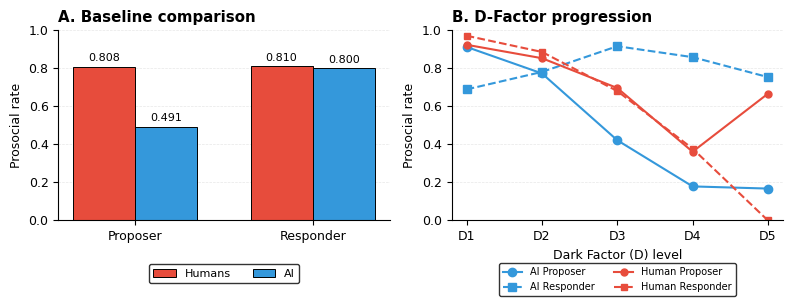

In [26]:

# Create figure with 2 subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8,3.2))

roles = ["proposer", "responder"]
# Compute rates
hum_rates, ai_rates = [], []
for role in roles:
    ai_rate  = ai_df.loc[ai_df["role"]==role, "prosocial"].mean()
    hum_rate = human_df.loc[human_df["role"]==role, "prosocial"].mean()
    hum_rates.append(float(hum_rate))
    ai_rates.append(float(ai_rate))

x = np.arange(len(roles))
w = 0.35

color_hum = "#E74C3C"  
color_ai  = "#3498DB"

bars_h = ax1.bar(x - w/2, hum_rates, width=w, label="Humans",
                 color=color_hum, edgecolor="black", linewidth=0.7)
bars_a = ax1.bar(x + w/2, ai_rates, width=w, label="AI",
                 color=color_ai, edgecolor="black", linewidth=0.7)

ax1.set_xticks(x)
ax1.set_xticklabels([r.capitalize() for r in roles])
ax1.set_ylim(0, 1)
ax1.set_ylabel("Prosocial rate", fontweight='medium')
ax1.set_title("A. Baseline comparison", fontweight='bold', loc='left')

ax1.yaxis.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax1.set_axisbelow(True)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

def annotate(ax, bars):
    for b in bars:
        h = b.get_height()
        if np.isfinite(h):
            ax.text(b.get_x() + b.get_width()/2, h + 0.02, f"{h:.3f}",
                    ha="center", va="bottom", fontsize=8, fontweight='light')

annotate(ax1, bars_h)
annotate(ax1, bars_a)

# AI data by D and role
ai_d_rates = ai_df.groupby(["role", "d_numeric"])["prosocial"].mean().unstack(0)

# Human data by D and role
human_df['d_binned'] = pd.cut(human_df['d_numeric'], bins=[0, 1.5, 2.5, 3.5, 4.5, 5.5], 
                                labels=[1, 2, 3, 4, 5]).astype(float)
human_d_rates = human_df.groupby(["role", "d_binned"])["prosocial"].mean().unstack(0)

# AI
# Proposer = SOLID, Responder = DASHED
ax2.plot(ai_d_rates.index, ai_d_rates['proposer'], 
         marker='o', markersize=6, linewidth=1.5, 
         color=color_ai, label='AI Proposer', linestyle='-')

ax2.plot(ai_d_rates.index, ai_d_rates['responder'], 
         marker='s', markersize=6, linewidth=1.5, 
         color=color_ai, label='AI Responder', linestyle='--')

# Human
# Proposer = SOLID, Responder = DASHED
ax2.plot(human_d_rates.index, human_d_rates['proposer'], 
         marker='o', markersize=5, linewidth=1.5, 
         color=color_hum, label='Human Proposer', linestyle='-')

ax2.plot(human_d_rates.index, human_d_rates['responder'], 
         marker='s', markersize=5, linewidth=1.5, 
         color=color_hum, label='Human Responder', linestyle='--')

ax2.set_xlabel('Dark Factor (D) level', fontweight='medium')
ax2.set_ylabel('Prosocial rate', fontweight='medium')
ax2.set_xticks([1, 2, 3, 4, 5])
ax2.set_xticklabels(['D1', 'D2', 'D3', 'D4', 'D5'])
ax2.set_ylim(0, 1)
ax2.set_yticks(np.arange(0, 1.1, 0.2))
ax2.set_title("B. D-Factor progression", fontweight='bold', loc='left')

ax2.yaxis.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax2.set_axisbelow(True)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=2, 
           frameon=True, edgecolor='black', fontsize=8)

ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=2, 
           frameon=True, edgecolor='black', fontsize=7)

plt.tight_layout()
plt.subplots_adjust(bottom=0.3)
#plt.savefig('figure_combined_baseline_and_d_progression.png', dpi=300, bbox_inches='tight')
plt.show()


## 5. Statistical Tables

Rates and confidence intervals

In [27]:


# Rebuild agg if missing
if "agg" not in globals():
    # HUMANS (bin D to 1..5)
    hum = human_df[["role","d_numeric","prosocial"]].dropna().copy()
    hum["D_level"] = np.clip(np.round(hum["d_numeric"]).astype(int), 1, 5)
    hum["source"]  = "Humans"

    # AI (D already 1..5)
    ai = ai_df[["role","d_numeric","prosocial"]].dropna().copy()
    ai["D_level"] = ai["d_numeric"].astype(int)
    ai["source"]  = "AI"

    both = pd.concat([hum[["role","source","D_level","prosocial"]],
                      ai[["role","source","D_level","prosocial"]]], ignore_index=True)

    D_levels = [1,2,3,4,5]
    idx = pd.MultiIndex.from_product([["proposer","responder"], ["Humans","AI"], D_levels],
                                     names=["role","source","D_level"])

    agg = (both.groupby(["role","source","D_level"])["prosocial"]
                .agg(s="sum", n="size")
                .reindex(idx)
                .reset_index())
    agg["rate"] = agg["s"] / agg["n"]
    ci = agg.apply(lambda r: proportion_confint(r["s"], r["n"], method="wilson")
                   if pd.notna(r["n"]) and r["n"]>0 else (np.nan, np.nan), axis=1, result_type="expand")
    ci.columns = ["ci_low","ci_high"]
    agg = pd.concat([agg, ci], axis=1)

# Pretty print: long table
print("=== Values used in barplots (long table) ===")
display(agg.sort_values(["role","D_level","source"])
        .round({"rate":3,"ci_low":3,"ci_high":3}))

# Pivoted tables per role: columns grouped by source, rows = D
for role in ["proposer","responder"]:
    sub = (agg[agg["role"]==role]
           .set_index(["D_level","source"])
           .sort_index())
    wide = sub[["rate","ci_low","ci_high","n","s"]].unstack("source")
    print(f"\n=== {role.capitalize()} — per-D values ===")
    display(wide.round(3))

    # Humans – AI rate differences per D (quick sanity)
    if ("rate","Humans") in wide.columns and ("rate","AI") in wide.columns:
        diff = (wide[("rate","Humans")] - wide[("rate","AI")]).to_frame("Humans - AI (rate)")
        print(f"--- {role.capitalize()} — Humans minus AI rate (per D) ---")
        display(diff.round(3))

# Optional: save to CSV for LaTeX/table tooling
out_path = "prelim_bar_CIs_values.csv"
agg.round(6).to_csv(out_path, index=False)
print(f"\nSaved detailed values to: {out_path}")


=== Values used in barplots (long table) ===


,role,source,D_level,s,n,rate,ci_low,ci_high
5,proposer,AI,1,31019.0,33994,0.912,0.909,0.915
0,proposer,Humans,1,161.0,175,0.920,0.870,0.952
6,proposer,AI,2,26289.0,33995,0.773,0.769,0.778
1,proposer,Humans,2,1190.0,1393,0.854,0.835,0.872
7,proposer,AI,3,14343.0,33995,0.422,0.417,0.427
2,proposer,Humans,3,293.0,421,0.696,0.650,0.738
8,proposer,AI,4,6088.0,33997,0.179,0.175,0.183
3,proposer,Humans,4,33.0,87,0.379,0.285,0.484
9,proposer,AI,5,5703.0,34000,0.168,0.164,0.172
4,proposer,Humans,5,2.0,3,0.667,0.208,0.939



=== Proposer — per-D values ===


rate        ci_low        ci_high             n               s  \
source      AI Humans     AI Humans      AI Humans     AI Humans       AI   
D_level                                                                     
1        0.912  0.920  0.909  0.870   0.915  0.952  33994    175  31019.0   
2        0.773  0.854  0.769  0.835   0.778  0.872  33995   1393  26289.0   
3        0.422  0.696  0.417  0.650   0.427  0.738  33995    421  14343.0   
4        0.179  0.379  0.175  0.285   0.183  0.484  33997     87   6088.0   
5        0.168  0.667  0.164  0.208   0.172  0.939  34000      3   5703.0   

                 
source   Humans  
D_level          
1         161.0  
2        1190.0  
3         293.0  
4          33.0  
5           2.0

--- Proposer — Humans minus AI rate (per D) ---


...


=== Responder — per-D values ===


rate        ci_low        ci_high             n               s  \
source      AI Humans     AI Humans      AI Humans     AI Humans       AI   
D_level                                                                     
1        0.689  0.977  0.684  0.934   0.694  0.992  34000    130  23434.0   
2        0.781  0.886  0.777  0.868   0.785  0.903  34000   1267  26556.0   
3        0.916  0.681  0.913  0.642   0.919  0.717  34000    595  31154.0   
4        0.859  0.387  0.855  0.294   0.862  0.489  34000     93  29199.0   
5        0.754  0.000  0.749  0.000   0.758  0.658  33975      2  25615.0   

                 
source   Humans  
D_level          
1         127.0  
2        1123.0  
3         405.0  
4          36.0  
5           0.0

--- Responder — Humans minus AI rate (per D) ---


,Humans - AI (rate)
D_level,
1,0.288
2,0.105
3,-0.236
4,-0.472
5,-0.754



Saved detailed values to: prelim_bar_CIs_values.csv


## 6. Logistic Regression

Prosocial behavior by D-factor (continuous)

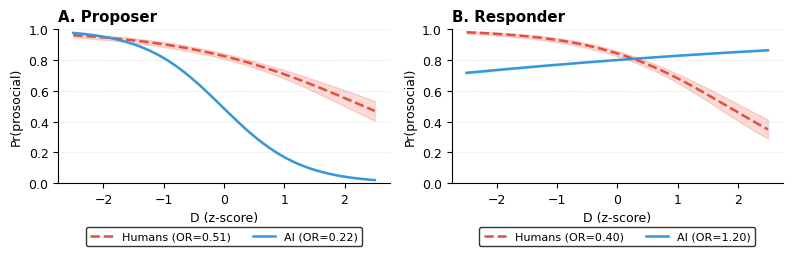


=== GLM Statistics: OR per +1 SD in D ===
     Role Source      n    OR         95% CI       z         p
 Proposer Humans   2079 0.510 [0.458, 0.568]  -12.28  1.12e-34
 Proposer     AI 169981 0.216 [0.213, 0.219] -211.02  0.00e+00
Responder Humans   2087 0.397 [0.352, 0.447]  -15.17  5.66e-52
Responder     AI 169975 1.202 [1.188, 1.217]   30.12 2.96e-199


In [28]:

# Colors
color_hum = "#E74C3C"  
color_ai  = "#3498DB"
ALPHA_FILL = 0.20

def fit_glm_predict_z(df, role):
    """Fit Binomial GLM: prosocial ~ D_z within (df, role), return OR(+1 SD), CI, and predicted curve."""
    sub = df.loc[df["role"] == role, ["d_numeric", "prosocial"]].dropna().copy()
    n = len(sub)
    if n == 0:
        return None
    # Standardize D within this subset
    mu, sd = sub["d_numeric"].mean(), sub["d_numeric"].std()
    sub["D_z"] = (sub["d_numeric"] - mu) / sd
    glm = smf.glm("prosocial ~ D_z", data=sub, family=sm.families.Binomial()).fit()

    beta = glm.params["D_z"]
    se   = glm.bse["D_z"]
    OR   = float(np.exp(beta))
    CI   = (float(np.exp(beta - 1.96*se)), float(np.exp(beta + 1.96*se)))
    zval = float(beta / se)
    pval = float(glm.pvalues["D_z"])

    # Common standardized grid
    z_grid = np.linspace(-2.5, 2.5, 200)
    Xg = pd.DataFrame({"const": 1.0, "D_z": z_grid})
    pred = glm.get_prediction(Xg).summary_frame()
    return {
        "n": n,
        "OR": OR,
        "CI": CI,
        "z": zval,
        "p": pval,
        "x": z_grid,
        "mean": pred["mean"].to_numpy(),
        "lo": pred["mean_ci_lower"].to_numpy(),
        "hi": pred["mean_ci_upper"].to_numpy(),
    }

# Fit models
hp = fit_glm_predict_z(human_df, "proposer")
hr = fit_glm_predict_z(human_df, "responder")
ap = fit_glm_predict_z(ai_df, "proposer")
ar = fit_glm_predict_z(ai_df, "responder")

# Create figure with 2 subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 2.5))

# Human
ax1.fill_between(hp["x"], hp["lo"], hp["hi"], color=color_hum, alpha=ALPHA_FILL)
ax1.plot(hp["x"], hp["mean"], color=color_hum, linestyle='--', linewidth=1.8,
        label=f"Humans (OR={hp['OR']:.2f})")
# AI
ax1.fill_between(ap["x"], ap["lo"], ap["hi"], color=color_ai, alpha=ALPHA_FILL)
ax1.plot(ap["x"], ap["mean"], color=color_ai, linestyle='-', linewidth=1.8,
        label=f"AI (OR={ap['OR']:.2f})")

ax1.set_xlabel("D (z-score)", fontweight='medium')
ax1.set_ylabel("Pr(prosocial)", fontweight='medium')
ax1.set_title("A. Proposer", fontweight='bold', loc='left')
ax1.set_ylim(0, 1)
ax1.set_yticks(np.arange(0, 1.1, 0.2))
ax1.yaxis.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax1.set_axisbelow(True)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Human
ax2.fill_between(hr["x"], hr["lo"], hr["hi"], color=color_hum, alpha=ALPHA_FILL)
ax2.plot(hr["x"], hr["mean"], color=color_hum, linestyle='--', linewidth=1.8,
        label=f"Humans (OR={hr['OR']:.2f})")
# AI
ax2.fill_between(ar["x"], ar["lo"], ar["hi"], color=color_ai, alpha=ALPHA_FILL)
ax2.plot(ar["x"], ar["mean"], color=color_ai, linestyle='-', linewidth=1.8,
        label=f"AI (OR={ar['OR']:.2f})")

ax2.set_xlabel("D (z-score)", fontweight='medium')
ax2.set_ylabel("Pr(prosocial)", fontweight='medium')
ax2.set_title("B. Responder", fontweight='bold', loc='left')
ax2.set_ylim(0, 1)
ax2.set_yticks(np.arange(0, 1.1, 0.2))
ax2.yaxis.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax2.set_axisbelow(True)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Legends
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=2, 
           frameon=True, edgecolor='black', fontsize=8)
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=2, 
           frameon=True, edgecolor='black', fontsize=8)

plt.tight_layout()
plt.subplots_adjust(bottom=0.25)

#plt.savefig('glm_standardized_by_role.png', dpi=300, bbox_inches='tight')
plt.show()

# Print stats table
print("\n=== GLM Statistics: OR per +1 SD in D ===")
stats_rows = [
    {"Role":"Proposer",  "Source":"Humans", "n":hp["n"], "OR":f"{hp['OR']:.3f}", 
     "95% CI":f"[{hp['CI'][0]:.3f}, {hp['CI'][1]:.3f}]", "z":f"{hp['z']:.2f}", "p":f"{hp['p']:.2e}"},
    {"Role":"Proposer",  "Source":"AI",     "n":ap["n"], "OR":f"{ap['OR']:.3f}", 
     "95% CI":f"[{ap['CI'][0]:.3f}, {ap['CI'][1]:.3f}]", "z":f"{ap['z']:.2f}", "p":f"{ap['p']:.2e}"},
    {"Role":"Responder", "Source":"Humans", "n":hr["n"], "OR":f"{hr['OR']:.3f}", 
     "95% CI":f"[{hr['CI'][0]:.3f}, {hr['CI'][1]:.3f}]", "z":f"{hr['z']:.2f}", "p":f"{hr['p']:.2e}"},
    {"Role":"Responder", "Source":"AI",     "n":ar["n"], "OR":f"{ar['OR']:.3f}", 
     "95% CI":f"[{ar['CI'][0]:.3f}, {ar['CI'][1]:.3f}]", "z":f"{ar['z']:.2f}", "p":f"{ar['p']:.2e}"},
]
print(pd.DataFrame(stats_rows).to_string(index=False))


## 7. Correlation Scatter

Model-level D-sensitivity

3 [-0.42484075  0.80900171]
7 [0.17734762 0.09073811]


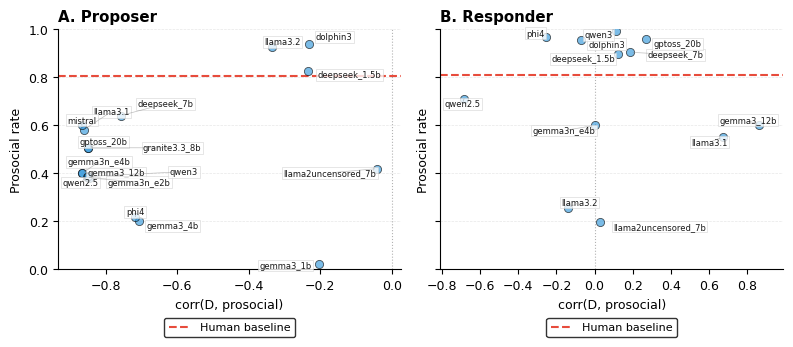


=== Model Heterogeneity Summary ===

Proposer: 17 models
  Prosocial rate range: [0.021, 0.938]
  Correlation range: [-0.866, -0.041]
  Human baseline: 0.808

Responder: 12 models
  Prosocial rate range: [0.196, 0.994]
  Correlation range: [-0.685, 0.866]
  Human baseline: 0.810


In [29]:
# Colors
color_ai = "#3498DB"
color_hum = "#E74C3C"

def safe_corr(x, y):
    x_ = pd.Series(x).astype(float)
    y_ = pd.Series(y).astype(float)
    if x_.nunique() < 2 or y_.nunique() < 2:
        return np.nan
    return float(np.corrcoef(x_, y_)[0, 1])
def summarize_role(df_ai, role):
    rows = []
    sub = df_ai[df_ai["role"] == role]
    for mdl, g in sub.groupby("model"):
        r = safe_corr(g["d_numeric"], g["prosocial"])
        rows.append({
            "model": mdl,
            "prosocial_rate": g["prosocial"].mean(),
            "r_d_prosocial": r,
            "n": len(g)
        })
    return pd.DataFrame(rows).dropna(subset=["r_d_prosocial"])

mdf_prop = summarize_role(ai_df, "proposer")
mdf_resp = summarize_role(ai_df, "responder")
# human baselines
hum_prop = human_df.loc[human_df["role"]=="proposer", "prosocial"].mean()
hum_resp = human_df.loc[human_df["role"]=="responder", "prosocial"].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3.65), sharey=True)
# Styles
EDGE = "black"
ALPHA = 0.65
LW = 0.6
MS = 35  # marker size

def draw_panel(ax, mdf, title, hline, panel_label):
    # Scatter
    ax.scatter(mdf["r_d_prosocial"], mdf["prosocial_rate"],
               s=MS, alpha=ALPHA, color=color_ai, 
               edgecolor=EDGE, linewidth=LW, zorder=3)
    
    # Human baseline
    ax.axhline(hline, linestyle='--', color=color_hum, linewidth=1.5, 
               label=f"Human baseline", zorder=2)
    
    # Zero correlation line
    ax.axvline(0, linestyle=':', color='gray', linewidth=0.8, alpha=0.6, zorder=1)
    
    ax.set_ylabel("Prosocial rate", fontweight='medium')
    ax.set_xlabel("corr(D, prosocial)", fontweight='medium')
    ax.set_title(f"{panel_label}. {title}", fontweight='bold', loc='left')
    ax.set_ylim(0, 1)
    ax.set_yticks(np.arange(0, 1.1, 0.2))
    
    # X-axis limits with padding
    xmin = float(np.nanmin(mdf["r_d_prosocial"])) if len(mdf) else -1
    xmax = float(np.nanmax(mdf["r_d_prosocial"])) if len(mdf) else 1
    pad = 0.08 * (xmax - xmin if xmax > xmin else 1.0)
    ax.set_xlim((xmin - pad, xmax + pad))
    
    ax.yaxis.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Add ALL labels using adjustText
    texts = []
    for _, row in mdf.iterrows():
        txt = ax.text(row["r_d_prosocial"], row["prosocial_rate"], 
                     row["model"],
                     fontsize=6, alpha=0.9,
                     ha="center", va="center",
                     bbox=dict(facecolor="white", edgecolor="lightgray", 
                              alpha=0.8, pad=1, linewidth=0.5))
        texts.append(txt)
    
    # Adjust text positions to avoid overlaps
    adjust_text(texts, ax=ax,
                arrowprops=dict(arrowstyle='-', color='gray', lw=0.5, alpha=0.5),
                expand_points=(1.5, 1.5),
                expand_text=(1.2, 1.2),
                force_points=(0.5, 0.5),
                force_text=(0.5, 0.5),
                lim=500)

# Draw panels
draw_panel(ax1, mdf_prop, "Proposer", hum_prop, "A")
draw_panel(ax2, mdf_resp, "Responder", hum_resp, "B")

# Legends
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=1, 
           frameon=True, edgecolor='black', fontsize=8)
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=1, 
           frameon=True, edgecolor='black', fontsize=8)

plt.tight_layout()
plt.subplots_adjust(bottom=0.25)

#plt.savefig("model_heterogeneity_all_labels.png", dpi=300, bbox_inches='tight')
plt.show()

# Print summary stats
print("\n=== Model Heterogeneity Summary ===")
print(f"\nProposer: {len(mdf_prop)} models")
print(f"  Prosocial rate range: [{mdf_prop['prosocial_rate'].min():.3f}, {mdf_prop['prosocial_rate'].max():.3f}]")
print(f"  Correlation range: [{mdf_prop['r_d_prosocial'].min():.3f}, {mdf_prop['r_d_prosocial'].max():.3f}]")
print(f"  Human baseline: {hum_prop:.3f}")

print(f"\nResponder: {len(mdf_resp)} models")
print(f"  Prosocial rate range: [{mdf_resp['prosocial_rate'].min():.3f}, {mdf_resp['prosocial_rate'].max():.3f}]")
print(f"  Correlation range: [{mdf_resp['r_d_prosocial'].min():.3f}, {mdf_resp['r_d_prosocial'].max():.3f}]")
print(f"  Human baseline: {hum_resp:.3f}")


## 8. Human-Likeness Analysis

Similarity metrics and model comparison

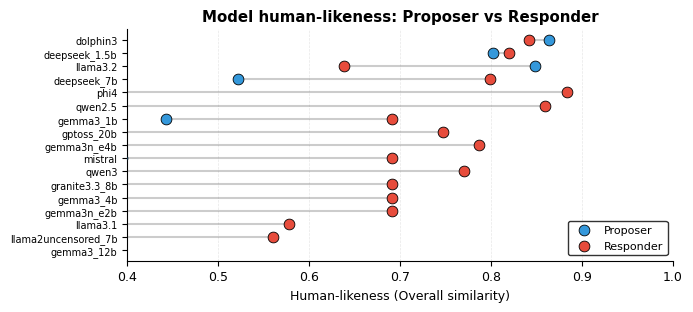


=== Models with Largest Role Differences ===
      model  Proposer  Responder  Difference
       phi4     0.319      0.884       0.565
    qwen2.5     0.312      0.859       0.547
gemma3n_e4b     0.309      0.787       0.478
      qwen3     0.313      0.770       0.457
 gptoss_20b     0.366      0.747       0.381

=== Most Consistent Models (smallest difference) ===
              model  Proposer  Responder  Difference
      deepseek_1.5b     0.802      0.820       0.018
           dolphin3     0.864      0.842       0.022
         gemma3_12b     0.309      0.219       0.090
           llama3.1     0.390      0.578       0.188
llama2uncensored_7b     0.359      0.560       0.201


In [30]:
# Colors
color_prop = "#3498DB"
color_resp = "#E74C3C"

METRICS = ["Prosocial rate", "D–prosocial r", "Odds ratio"]

def safe_pointbiserial(y, x):
    y = pd.Series(y).astype(float)
    x = pd.Series(x).astype(float)
    if y.nunique() < 2 or x.nunique() < 2:
        return np.nan, np.nan
    r = stats.pointbiserialr(y, x)
    return (getattr(r, "statistic", r[0]), getattr(r, "pvalue", r[1]))

def safe_or(x, y):
    x = np.asarray(x, dtype=float).reshape(-1, 1)
    y = np.asarray(y, dtype=int)
    if np.unique(y).size < 2 or np.unique(x).size < 2:
        return np.nan
    try:
        lr = LogisticRegression(solver="lbfgs", max_iter=2000)
        lr.fit(x, y)
        return float(np.exp(lr.coef_[0, 0]))
    except Exception:
        return np.nan

def human_benchmarks(human_df, role):
    H = human_df.loc[human_df["role"]==role, ["d_numeric","prosocial"]].dropna()
    pr = H["prosocial"].mean()
    r, _ = safe_pointbiserial(H["prosocial"], H["d_numeric"])
    orv = safe_or(H["d_numeric"], H["prosocial"])
    return np.array([pr, r, orv], dtype=float)

def per_model_metrics(ai_df, role):
    rows = []
    A = ai_df.loc[ai_df["role"]==role, ["model","d_numeric","prosocial"]].dropna()
    for m, g in A.groupby("model", sort=False):
        pr = g["prosocial"].mean()
        r, _ = safe_pointbiserial(g["prosocial"], g["d_numeric"])
        orv = safe_or(g["d_numeric"], g["prosocial"])
        rows.append({"model": m, METRICS[0]: pr, METRICS[1]: r, METRICS[2]: orv})
    return pd.DataFrame(rows).set_index("model")

def to_similarity(df_metrics, human_vec):
    sim = df_metrics.copy().astype(float)
    for j, col in enumerate(METRICS):
        dist = np.abs(sim[col] - human_vec[j])
        if np.all(~np.isfinite(dist)) or np.nanmax(dist) == 0:
            sim[col] = 1.0
        else:
            sim[col] = 1.0 - (dist / np.nanmax(dist))
    return sim

hp = human_benchmarks(human_df, "proposer")
hr = human_benchmarks(human_df, "responder")
ap_raw = per_model_metrics(ai_df, "proposer")
ar_raw = per_model_metrics(ai_df, "responder")

ap_sim = to_similarity(ap_raw, hp)
ar_sim = to_similarity(ar_raw, hr)

# Overall scores
ap_sim["Overall"] = ap_sim[METRICS].mean(axis=1)
ar_sim["Overall"] = ar_sim[METRICS].mean(axis=1)

# Merge
all_models = sorted(set(ap_sim.index) | set(ar_sim.index))
dot_data = pd.DataFrame({
    "model": all_models,
    "Proposer": [ap_sim.loc[m, "Overall"] if m in ap_sim.index else np.nan for m in all_models],
    "Responder": [ar_sim.loc[m, "Overall"] if m in ar_sim.index else np.nan for m in all_models]
})

# Sort by average
dot_data["Average"] = dot_data[["Proposer", "Responder"]].mean(axis=1)
dot_data = dot_data.sort_values("Average", ascending=True).reset_index(drop=True)

n_models = len(dot_data)
fig_height = max(3.2, 0.15 * n_models)
fig, ax = plt.subplots(1, 1, figsize=(7, fig_height))
y_pos = np.arange(n_models)

# Draw connecting lines
for i, row in dot_data.iterrows():
    ax.plot([row["Proposer"], row["Responder"]], [i, i], 
            color='gray', linewidth=1.5, alpha=0.4, zorder=1)

# Draw dots
ax.scatter(dot_data["Proposer"], y_pos, 
          s=60, color=color_prop, edgecolor='black', linewidth=0.6,
          label="Proposer", zorder=3)
ax.scatter(dot_data["Responder"], y_pos, 
          s=60, color=color_resp, edgecolor='black', linewidth=0.6,
          label="Responder", zorder=3)

ax.set_yticks(y_pos)
ax.set_yticklabels(dot_data["model"], fontsize=7)
ax.set_xlabel("Human-likeness (Overall similarity)", fontweight='medium')
ax.set_title("Model human-likeness: Proposer vs Responder", fontweight='bold')
ax.set_xlim(0.4, 1)
ax.xaxis.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(loc='lower right', frameon=True, edgecolor='black', fontsize=8)

plt.tight_layout()
plt.savefig("human_likeness_cleveland.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n=== Models with Largest Role Differences ===")
dot_data["Difference"] = abs(dot_data["Proposer"] - dot_data["Responder"])
print(dot_data.nlargest(5, "Difference")[["model", "Proposer", "Responder", "Difference"]].round(3).to_string(index=False))

print("\n=== Most Consistent Models (smallest difference) ===")
print(dot_data.nsmallest(5, "Difference")[["model", "Proposer", "Responder", "Difference"]].round(3).to_string(index=False))


## 9. Diagnostics & Rankings

Validation and detailed statistics

In [31]:

METRICS = ["Prosocial rate", "D–prosocial r", "Odds ratio"]
def constant_outcome_table(df_ai, role):
    A = df_ai[df_ai["role"]==role]
    t = A.groupby("model")["prosocial"].agg(rate="mean", n="size", unique=lambda s: s.nunique())
    const = t[t["unique"]==1].drop(columns="unique").sort_values("rate", ascending=False)
    return const

print("\n=== Constant outcomes (prosocial all 0 or all 1) — Proposer ===")
display(constant_outcome_table(ai_df, "proposer").round(3))
print("\n=== Constant outcomes (prosocial all 0 or all 1) — Responder ===")
display(constant_outcome_table(ai_df, "responder").round(3))

nan_summary = pd.DataFrame({
    "Proposer (NaNs)": ap_sim[METRICS].isna().sum(),
    "Responder (NaNs)": ar_sim[METRICS].isna().sum()
})
print("\n=== NaN counts in similarity-by-metric (usually from constant outcomes or OR failures) ===")
display(nan_summary)
def rank_by_mean(sim_df, top=5, bottom=5):
    r = sim_df.assign(mean_sim=sim_df.mean(axis=1))
    return r.sort_values("mean_sim", ascending=False).head(top), r.sort_values("mean_sim", ascending=True).head(bottom)
top_p, bot_p = rank_by_mean(ap_sim)
top_r, bot_r = rank_by_mean(ar_sim)

print("\n=== Proposer — Top/Bottom by mean similarity ===")
display(top_p[["mean_sim"]].round(2))
display(bot_p[["mean_sim"]].round(2))

print("\n=== Responder — Top/Bottom by mean similarity ===")
display(top_r[["mean_sim"]].round(2))
display(bot_r[["mean_sim"]].round(2))

all_idx = sorted(set(ap_sim.index) | set(ar_sim.index))
overall = pd.DataFrame(index=all_idx)
overall["Proposer_mean"]  = ap_sim.mean(axis=1)
overall["Responder_mean"] = ar_sim.mean(axis=1)
overall["Overall_mean"]   = overall[["Proposer_mean","Responder_mean"]].mean(axis=1)
print("\n=== Overall human-likeness (avg across roles) — Top 10 ===")
display(overall.sort_values("Overall_mean", ascending=False).head(10).round(2))
div = (overall["Proposer_mean"] - overall["Responder_mean"]).abs().sort_values(ascending=False)
div_df = div.to_frame("abs(Proposer_mean − Responder_mean)")
print("\n=== Role divergence (absolute difference in mean similarity) — Top 10 ===")
display(div_df.head(10).round(2))
#ap_sim.round(3).to_csv("human_likeness_similarity_proposer.csv")
#ar_sim.round(3).to_csv("human_likeness_similarity_responder.csv")
#overall.round(3).to_csv("human_likeness_similarity_overall.csv")
#print("\nSaved: human_likeness_similarity_proposer.csv, human_likeness_similarity_responder.csv, human_likeness_similarity_overall.csv")



=== Constant outcomes (prosocial all 0 or all 1) — Proposer ===


,rate,n
model,,



=== Constant outcomes (prosocial all 0 or all 1) — Responder ===


,rate,n
model,,
gemma3_1b,1.0,10000
gemma3_4b,1.0,10000
gemma3n_e2b,1.0,10000
granite3.3_8b,1.0,10000
mistral,1.0,10000



=== NaN counts in similarity-by-metric (usually from constant outcomes or OR failures) ===


...

,mean_sim
model,
gemma3_12b,0.22
llama2uncensored_7b,0.56
llama3.1,0.58
llama3.2,0.64
gemma3n_e2b,0.69



=== Overall human-likeness (avg across roles) — Top 10 ===


,Proposer_mean,Responder_mean,Overall_mean
dolphin3,0.86,0.84,0.85
deepseek_1.5b,0.80,0.82,0.81
llama3.2,0.85,0.64,0.74
deepseek_7b,0.52,0.80,0.66
phi4,0.32,0.88,0.60
qwen2.5,0.31,0.86,0.59
gemma3_1b,0.44,0.69,0.57
gptoss_20b,0.37,0.75,0.56
gemma3n_e4b,0.31,0.79,0.55
mistral,0.39,0.69,0.54



=== Role divergence (absolute difference in mean similarity) — Top 10 ===


,abs(Proposer_mean − Responder_mean)
phi4,0.56
qwen2.5,0.55
gemma3n_e4b,0.48
qwen3,0.46
gptoss_20b,0.38
gemma3n_e2b,0.38
gemma3_4b,0.37
granite3.3_8b,0.33
mistral,0.30
deepseek_7b,0.28


## 10. Temperature Effects

Heatmap visualization

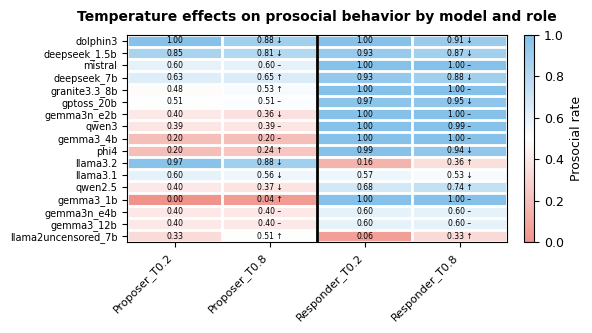


=== Temperature Effects Summary ===

PROPOSER:
  Mean change (T0.8 - T0.2): -0.002
  Mean absolute change: 0.039
  Most sensitive model: llama2uncensored_7b (Δ=0.172)
  Least sensitive model: gemma3_12b (Δ=0.000)
  Models increasing with T: 6/17
  Models decreasing with T: 7/17

RESPONDER:
  Mean change (T0.8 - T0.2): +0.013
  Mean absolute change: 0.049
  Most sensitive model: llama2uncensored_7b (Δ=0.270)
  Least sensitive model: gemma3_12b (Δ=0.000)
  Models increasing with T: 3/17
  Models decreasing with T: 7/17


In [32]:
# --- Model × Temperature × Role summary ---
model_temp_results = []
for (model, temp, role), df_mtr in ai_df.groupby(["model","temperature", "role"]):
    if len(df_mtr) < 5 or df_mtr["prosocial"].nunique() < 2:
        corr_val = np.nan
    else:
        corr = stats.pointbiserialr(df_mtr["prosocial"], df_mtr["d_numeric"])
        corr_val = corr.statistic
    model_temp_results.append({
        "model": model,
        "temperature": temp,
        "role": role,
        "prosocial_rate": df_mtr["prosocial"].mean(),
        "correlation": corr_val,
        "n_obs": len(df_mtr)
    })

model_temp_df = pd.DataFrame(model_temp_results)

# Create column names for heatmap: Role_Temp
model_temp_df["col_name"] = model_temp_df["role"].str.capitalize() + "_T" + model_temp_df["temperature"].astype(str)

# Pivot to create heatmap data
pivot = model_temp_df.pivot(index="model", columns="col_name", values="prosocial_rate")

# Reorder columns: Proposer_T0.2, Proposer_T0.8, Responder_T0.2, Responder_T0.8
col_order = ["Proposer_T0.2", "Proposer_T0.8", "Responder_T0.2", "Responder_T0.8"]
pivot = pivot[[c for c in col_order if c in pivot.columns]]

# Sort models by average prosocial rate
pivot["avg"] = pivot.mean(axis=1)
pivot = pivot.sort_values("avg", ascending=False).drop(columns="avg")

# --- Plotting ---
n_models = len(pivot)
fig_height = max(3.1, 0.2 * n_models)
fig, ax = plt.subplots(1, 1, figsize=(6, fig_height))

# Lighter blue to orange colormap using user's colors
# Lighten the colors by blending with white
def lighten_color(hex_color, amount=0.5):
    """Lighten a hex color by blending with white"""
    # Remove '#' and convert to RGB
    hex_color = hex_color.lstrip('#')
    r, g, b = tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))
    # Blend with white
    r = int(r + (255 - r) * amount)
    g = int(g + (255 - g) * amount)
    b = int(b + (255 - b) * amount)
    return f'#{r:02x}{g:02x}{b:02x}'

light_hum = lighten_color(color_hum, 0.4)  # Lighter red
light_ai = lighten_color(color_ai, 0.4)    # Lighter blue

colors = [light_hum, '#FFFFFF', light_ai]  # Light red -> White -> Light blue
cmap = LinearSegmentedColormap.from_list('blue_orange', colors)
cmap.set_bad(color="#E0E0E0", alpha=0.6)

# Create masked array for NaNs
Mvals = pivot.values.astype(float)
Mmasked = np.ma.array(Mvals, mask=~np.isfinite(Mvals))

# Draw heatmap
im = ax.imshow(Mmasked, aspect="auto", cmap=cmap, vmin=0.0, vmax=1.0)

# Add annotations with arrows for temperature changes
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = Mvals[i, j]
        if np.isfinite(val):
            text = f"{val:.2f}"
            
            # Add arrow for T0.8 columns (comparing to T0.2)
            col_name = pivot.columns[j]
            if "T0.8" in col_name:
                role = col_name.split("_")[0]  # "Proposer" or "Responder"
                t02_col = f"{role}_T0.2"
                if t02_col in pivot.columns:
                    t02_idx = list(pivot.columns).index(t02_col)
                    t02_val = Mvals[i, t02_idx]
                    if np.isfinite(t02_val):
                        diff = val - t02_val
                        if abs(diff) < 0.01:
                            arrow = "–"  # dash for no change
                        elif diff > 0:
                            arrow = "↑"  # up arrow
                        else:
                            arrow = "↓"  # down arrow
                        text = f"{val:.2f} {arrow}"
            
            ax.text(j, i, text, ha="center", va="center", 
                   fontsize=5.5, color='black', weight='normal')

# Set ticks
ax.set_yticks(np.arange(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=7)
ax.set_xticks(np.arange(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, fontsize=8, rotation=45, ha='right')

ax.set_title("Temperature effects on prosocial behavior by model and role", 
             fontweight='bold', fontsize=10, pad=10)

# Add grid
ax.set_xticks(np.arange(len(pivot.columns)+1)-.5, minor=True)
ax.set_yticks(np.arange(len(pivot.index)+1)-.5, minor=True)
ax.grid(which="minor", color="white", linestyle='-', linewidth=2)
ax.tick_params(which="minor", size=0)

# Add vertical separator between proposer and responder
ax.axvline(1.5, color='black', linewidth=2, zorder=10)

# Colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Prosocial rate", fontsize=9)

plt.tight_layout()
#plt.savefig("temperature_heatmap.png", dpi=300, bbox_inches='tight')
plt.savefig("temperature_heatmap.pdf", bbox_inches='tight')
plt.show()

# --- Summary statistics ---
print("\n=== Temperature Effects Summary ===")

# Calculate temperature sensitivity for each role
for role in ["proposer", "responder"]:
    role_df = model_temp_df[model_temp_df["role"]==role]
    pivot_role = role_df.pivot(index="model", columns="temperature", values="prosocial_rate").dropna()
    
    if 0.2 in pivot_role.columns and 0.8 in pivot_role.columns:
        pivot_role["delta"] = pivot_role[0.8] - pivot_role[0.2]
        pivot_role["abs_delta"] = abs(pivot_role["delta"])
        
        print(f"\n{role.upper()}:")
        print(f"  Mean change (T0.8 - T0.2): {pivot_role['delta'].mean():+.3f}")
        print(f"  Mean absolute change: {pivot_role['abs_delta'].mean():.3f}")
        print(f"  Most sensitive model: {pivot_role['abs_delta'].idxmax()} (Δ={pivot_role['abs_delta'].max():.3f})")
        print(f"  Least sensitive model: {pivot_role['abs_delta'].idxmin()} (Δ={pivot_role['abs_delta'].min():.3f})")
        print(f"  Models increasing with T: {(pivot_role['delta'] > 0).sum()}/{len(pivot_role)}")
        print(f"  Models decreasing with T: {(pivot_role['delta'] < 0).sum()}/{len(pivot_role)}")


## 11. Tipping Point Analysis

D-level where models switch to selfish behavior

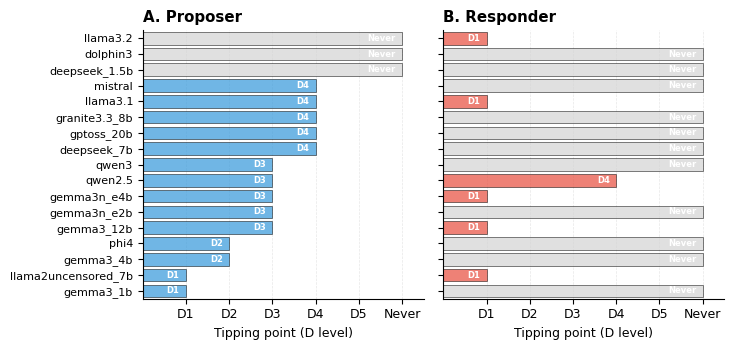


=== TIPPING POINT ANALYSIS ===

Definition: First D level where prosocial rate drops below 0.5

PROPOSER:
  Total models: 17
  Models that tip: 14 (82.4%)
  Models that never tip: 3 (17.6%)
  Mean tipping point: D2.93
  Median tipping point: D3
  Mode (most common): D3
  Distribution:
    D1: 2 models (14.3%)
    D2: 2 models (14.3%)
    D3: 5 models (35.7%)
    D4: 5 models (35.7%)
  Early tippers (D1-D2): 4 models
  Late tippers (D4-D5): 5 models
  Average decline (D1→D5): 0.862

RESPONDER:
  Total models: 17
  Models that tip: 6 (35.3%)
  Models that never tip: 11 (64.7%)
  Mean tipping point: D1.50
  Median tipping point: D1
  Mode (most common): D1
  Distribution:
    D1: 5 models (83.3%)
    D4: 1 models (16.7%)
  Early tippers (D1-D2): 5 models
  Late tippers (D4-D5): 1 models
  Average decline (D1→D5): -0.131

=== COMPLETE MODEL RANKING ===

PROPOSER (sorted by tipping point):
              model tp_label  D1_rate  D5_rate  decline
          gemma3_1b       D1    0.102    0.00

In [33]:
# Colors
color_prop = "#3498DB"
color_resp = "#E74C3C"

levels = [1, 2, 3, 4, 5]
# Per-model curves (AI; average across temperatures)
pm = (ai_df.assign(d_int=ai_df["d_numeric"].round().astype(int))
            .groupby(["model", "role", "d_int"], observed=False)["prosocial"]
            .mean()
            .reset_index())

def find_tipping_point(model_data, threshold=0.5):
    """
    Find the D level where prosocial rate crosses below threshold.
    Returns the first D level where rate < threshold, or None if never crosses.
    """
    model_data = model_data.set_index("d_int")["prosocial"].reindex(levels)
    # Find first level below threshold
    for d in levels:
        if pd.notna(model_data.get(d)) and model_data.get(d) < threshold:
            return d
    
    # If never crosses, return None (always prosocial)
    return None

tipping_points = []
for (model, role), g in pm.groupby(["model", "role"]):
    tp = find_tipping_point(g.copy())
    
    # Also get the prosocial rates at each D level
    rates = g.set_index("d_int")["prosocial"].reindex(levels).to_dict()
    
    tipping_points.append({
        "model": model,
        "role": role,
        "tipping_point": tp if tp is not None else 6,  # 6 = never tips
        "D1_rate": rates.get(1, np.nan),
        "D5_rate": rates.get(5, np.nan),
        "decline": rates.get(1, np.nan) - rates.get(5, np.nan) if pd.notna(rates.get(1)) and pd.notna(rates.get(5)) else np.nan
    })

tp_df = pd.DataFrame(tipping_points)

n_models = len(tp_df["model"].unique())
fig_height = max(1.2, n_models * 0.21)  # More space per model
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, fig_height))
# Get consistent model order across both roles (sort by proposer tipping point, then model name)
prop_data = tp_df[tp_df["role"] == "proposer"].sort_values(["tipping_point", "model"], ascending=[True, True])
model_order = prop_data["model"].tolist()

for ax, role, color, panel in [(ax1, "proposer", color_prop, "A"), 
                                (ax2, "responder", color_resp, "B")]:
    role_data = tp_df[tp_df["role"] == role].copy()
    
    # Sort by the consistent model order
    role_data["model"] = pd.Categorical(role_data["model"], categories=model_order, ordered=True)
    role_data = role_data.sort_values("model")
    
    y_pos = np.arange(len(role_data))
    
    # Color bars: models that never tip in gray, others in role color
    bar_colors = [color if tp < 6 else 'lightgray' for tp in role_data["tipping_point"]]
    
    # Horizontal bars
    bars = ax.barh(y_pos, role_data["tipping_point"], 
                   color=bar_colors, edgecolor='black', linewidth=0.5, alpha=0.7)
    
    # Add tipping point labels on bars
    for i, (bar, tp) in enumerate(zip(bars, role_data["tipping_point"])):
        if tp < 6:
            label = f"D{int(tp)}"
        else:
            label = "Never"
        ax.text(bar.get_width() - 0.15, bar.get_y() + bar.get_height()/2, 
               label, ha='right', va='center', fontsize=6, 
               color='white', weight='bold')
    
    ax.set_yticks(y_pos)
    if panel == "A":  # Only show labels on left panel
        ax.set_yticklabels(role_data["model"], fontsize=8)
    else:
        ax.set_yticklabels([])
    ax.set_ylim(-0.5, len(role_data) - 0.5)  # Set proper y limits
    ax.set_xlabel("Tipping point (D level)", fontweight='medium')
    ax.set_title(f"{panel}. {role.capitalize()}", fontweight='bold', loc='left')
    ax.set_xlim(0, 6.5)
    ax.set_xticks([1, 2, 3, 4, 5, 6])
    ax.set_xticklabels(['D1', 'D2', 'D3', 'D4', 'D5', 'Never'])
    ax.xaxis.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.subplots_adjust(left=0.15)  # More space for model names

#plt.savefig("tipping_points_all_models.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n=== TIPPING POINT ANALYSIS ===")
print("\nDefinition: First D level where prosocial rate drops below 0.5")
for role in ["proposer", "responder"]:
    print(f"\n{role.upper()}:")
    role_data = tp_df[tp_df["role"] == role]
    
    # Basic stats
    tippers = role_data[role_data["tipping_point"] < 6]
    never = role_data[role_data["tipping_point"] == 6]
    
    print(f"  Total models: {len(role_data)}")
    print(f"  Models that tip: {len(tippers)} ({len(tippers)/len(role_data)*100:.1f}%)")
    print(f"  Models that never tip: {len(never)} ({len(never)/len(role_data)*100:.1f}%)")
    
    if len(tippers) > 0:
        print(f"  Mean tipping point: D{tippers['tipping_point'].mean():.2f}")
        print(f"  Median tipping point: D{tippers['tipping_point'].median():.0f}")
        print(f"  Mode (most common): D{tippers['tipping_point'].mode().iloc[0]:.0f}")
        
        # Distribution
        print(f"  Distribution:")
        for d in [1, 2, 3, 4, 5]:
            count = (tippers["tipping_point"] == d).sum()
            if count > 0:
                print(f"    D{d}: {count} models ({count/len(tippers)*100:.1f}%)")
    
    # Early vs late tippers
    if len(tippers) > 0:
        early = tippers[tippers["tipping_point"] <= 2]
        late = tippers[tippers["tipping_point"] >= 4]
        print(f"  Early tippers (D1-D2): {len(early)} models")
        print(f"  Late tippers (D4-D5): {len(late)} models")
        
        # Average decline for tippers
        print(f"  Average decline (D1→D5): {tippers['decline'].mean():.3f}")

print("\n=== COMPLETE MODEL RANKING ===")
for role in ["proposer", "responder"]:
    print(f"\n{role.upper()} (sorted by tipping point):")
    role_data = tp_df[tp_df["role"] == role].sort_values("tipping_point")
    # Format tipping point
    role_data["tp_label"] = role_data["tipping_point"].apply(
        lambda x: f"D{int(x)}" if x < 6 else "Never"
    )
    print(role_data[["model", "tp_label", "D1_rate", "D5_rate", "decline"]].round(3).to_string(index=False))
